In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL6_flip3_18mar]

In [ ]:
%load_ext autoreload
%autoreload 2
from settings.settings_analyze_efizz import Settings_ae as settings
from behave_analysis.process.process import Process
from behave_analysis.analyze.analyze_efizz import AnalyzeEfizz
from settings.settings_overrides import settings_overrides
from behave_analysis.analyze.results_database_utils import check_database_for_same_run, settings_to_check
from behave_analysis.analyze.PlaceCells.PlaceCells import PlaceCells
from behave_analysis.utils.arena_plotting import Arena
from behave_analysis.analyze.EscapePattern.escape_pattern_utils import compute_tuning_stat

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import polars as pl
from mpl_toolkits.axes_grid1 import make_axes_locatable
settings = settings_overrides(settings, {'redo_compute': False,                  
                                        'linshift_min_step': 120,
                                        'linshift_step': 80})
%matplotlib inline
COLUMNS_TO_KEEP = ["frames",
                "mouse_x_position",
                "mouse_y_position",
                "spike_clusters",
                "spike_count",
                "OutofshelterIdx",
                "EscapePeriod",
                "shelter",
                "barrier_present",
                "barrier_flipped",
                "homingPeriod",
                "speed",
            ]
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF

cond_list = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# quick hardcoded version!
session = Process(experiments_objects[0]).load_session()
# load PC for exploration
PC_dict = np.load(r"Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\place_cells\PC_082beded816c4911_results.npz", allow_pickle=True)

# load PC for homings
PC_homie_dict = np.load(r"Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\place_cells\PC_eeb177067ee2461a_results.npz", allow_pickle=True)

# load escape tuning for escape periods
# tuning for ALL homings&escapes
escp_tuna_dict = np.load(r"Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\escape_tuning\EPtuning_2e172a4b775444bc_results.npz", allow_pickle=True)
# tuning only for correct and long escapes
# escp_tuna_dict = np.load(r"Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\escape_tuning\EPtuning_fa4635b40b8c4393_results.npz", allow_pickle=True)

stat = "zscore_peak"
real_stat, shift_stat = compute_tuning_stat(stat=stat, 
                                            shifted_matrix=escp_tuna_dict['fr_shift'], 
                                            shift0=int(np.shape(escp_tuna_dict['fr_shift'])[0] / 2), 
                                            neural_matrix=escp_tuna_dict['neural_matrix'], 
                                            condition=escp_tuna_dict['condition'])
sig_escape = real_stat > np.nanpercentile(shift_stat, 95, axis=0)

2026-03-25 07:52:20.783 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


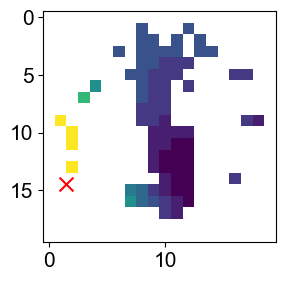

In [34]:
import numpy as np
from scipy.optimize import curve_fit

def gaussian_2d(coords, amplitude, xo, yo, sigma_x, sigma_y, offset):
    x, y = coords
    inner = ((x - xo)**2 / (2 * sigma_x**2)) + ((y - yo)**2 / (2 * sigma_y**2))
    return amplitude * np.exp(-inner) + offset

def fit_peak_circular_2d(rate_map):
    rows, cols = rate_map.shape
    y_grid, x_grid = np.indices((rows, cols))
    
    # 1. Define the Arena Mask (Valid Bins)
    mask = ~np.isnan(rate_map)
    if not np.any(mask): return None
    
    # 2. Get Circle Parameters (Center & Radius of the visited area)
    y_visited, x_visited = np.where(mask)
    x_c, y_c = np.mean(x_visited), np.mean(y_visited)
    radius = np.max(np.sqrt((x_visited - x_c)**2 + (y_visited - y_c)**2))

    # 3. Filter data for the solver
    x_data = x_grid[mask].ravel()
    y_data = y_grid[mask].ravel()
    z_data = rate_map[mask].ravel()
    coords_data = np.vstack((x_data, y_data))

    # 4. Define Bounded Constraints
    # [amp, xo, yo, sig_x, sig_y, offset]
    # We restrict xo and yo to stay within the estimated circle
    lower_bounds = [0, x_c - radius, y_c - radius, 0.5, 0.5, -np.inf]
    upper_bounds = [np.inf, x_c + radius, y_c + radius, radius, radius, np.inf]
    
    # 5. Initial Guess (using empirical peak)
    max_idx = np.nanargmax(rate_map)
    iy, ix = np.unravel_index(max_idx, rate_map.shape)
    initial_guess = (np.nanmax(rate_map), ix, iy, 3, 3, np.nanmin(rate_map))

    # 6. Fit
    try:
        popt, _ = curve_fit(gaussian_2d, coords_data, z_data, 
                            p0=initial_guess, 
                            bounds=(lower_bounds, upper_bounds))
        
        # Final check: Is the fitted center mathematically inside the circle?
        fit_xo, fit_yo = popt[1], popt[2]
        dist_from_center = np.sqrt((fit_xo - x_c)**2 + (fit_yo - y_c)**2)
        
        if dist_from_center > radius:
            # If the fit drifted out, we force it to the edge of the circle
            # Or handle as an edge-case
            pass
            
        return popt # [amplitude, xo, yo, sigma_x, sigma_y, offset]
    except Exception as e:
        print(f"Fit failed: {e}")
        return None

c = cond_list[0]
i = 4
rate_map = PC_homie_dict[c].item()['rate_map'][:,:,i]
fig, axs = plt.subplots(1,1, figsize=(3, 3))
axs.imshow(PC_homie_dict[c].item()['rate_map'][:,:,i], aspect='auto')
popt = fit_peak_circular_2d(rate_map)
axs.scatter(popt[1], popt[2], color='red', marker='x', s=100, label='Fitted Peak')
        

In [40]:
for k in escp_tuna_dict.keys():
    print(k, escp_tuna_dict[k].shape)

name ()
nbins ()
tuning_var ()
settings ()
escape_pattern_time ()
bin_edges (26,)
savepath ()
homing_vector (1456228,)
escape_vector (1456228,)
explore_vector ()
neural_matrix (274, 45628)
condition (45628,)
discretized_var (45628, 1)
loo_reliability ()
R_full ()
y_fitted_full (3, 274, 25)
fr_full (3, 274, 25)
params_full (274, 3, 6)
mat_num_cond (3, 274, 152, 25)
shifts (101,)
y_fitted_shift (101, 3, 274, 25)
R_shift ()
fr_shift (101, 3, 274, 25)
params_shifts (101, 274, 3, 6)
mat_shift_cond (101, 3, 274, 114, 25)
loo_shift ()
discretized_var_shift (29342, 1)
residual_var2_t1 ()
residual_fr_var2_t2 ()
allow_pickle ()


In [45]:
bins

array([0.02, 0.06, 0.1 , 0.14, 0.18, 0.22, 0.26, 0.3 , 0.34, 0.38, 0.42,
       0.46, 0.5 , 0.54, 0.58, 0.62, 0.66, 0.7 , 0.74, 0.78, 0.82, 0.86,
       0.9 , 0.94, 0.98])

In [ ]:
np.nanmax(np.append([np.nanmax(PC_dict[c].item()['rate_map'][:,:,0]) for c in cond_list],[np.nanmax(PC_homie_dict[c].item()['rate_map'][:,:,0]) for c in cond_list]))

array([ 9.,  9., 10.,  4.,  4.,  3.])

In [59]:
from syd import make_viewer

viewer = make_viewer()
viewer.add_integer("neuron", min = 0, max = PC_dict['shelter_only'].item()['rate_map'].shape[2]-1)
bins = escp_tuna_dict['bin_edges'][:-1] + np.diff(escp_tuna_dict['bin_edges']) / 2

def plot(state):
    neuron = state['neuron']
    vmax_exp = np.nanmax([np.nanmax(PC_dict[c].item()['rate_map'][:,:,neuron]) for c in cond_list])
    vmax_homie = np.nanmax([np.nanmax(PC_homie_dict[c].item()['rate_map'][:,:,neuron]) for c in cond_list])
    vmax = max(vmax_exp, vmax_homie)
    vmin_exp = np.nanmin([np.nanmin(PC_dict[c].item()['rate_map'][:,:,neuron]) for c in cond_list])
    vmin_homie = np.nanmin([np.nanmin(PC_homie_dict[c].item()['rate_map'][:,:,neuron]) for c in cond_list])
    vmin = min(vmin_exp, vmin_homie)
    fig, axs = plt.subplots(3,3, figsize=(10, 10))
    for c in cond_list:
        # the rows are conditions, the columns are tuning curve, rate map in explore, rate map in homie
        # rate map in explore
        rate_map = PC_dict[c].item()['rate_map'][:,:,neuron]
        Arena(ax = axs[cond_list.index(c), 0], dim = PC_dict[c].item()["rate_map"][:,:,neuron].shape[0]-1, condition = c,
                barrier_coordinates = session.barrier_location[:-1], full_image = False)
        im = axs[cond_list.index(c), 0].imshow(rate_map, aspect='auto', vmin = vmin_exp, vmax = vmax_exp)
        popt = fit_peak_circular_2d(rate_map)
        axs[cond_list.index(c), 0].scatter(popt[1], popt[2], color='red', marker='x', s=50)
        if cond_list.index(c) == 0:
            divider = make_axes_locatable(axs[cond_list.index(c), 0])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            plt.colorbar(im, cax=cax)
        # rate map in homie
        rate_map = PC_homie_dict[c].item()['rate_map'][:,:,neuron]
        Arena(ax = axs[cond_list.index(c), 1], dim = PC_homie_dict[c].item()["rate_map"][:,:,neuron].shape[0]-1, condition = c,
                barrier_coordinates = session.barrier_location[:-1], full_image = False)
        im = axs[cond_list.index(c), 1].imshow(rate_map, aspect='auto', vmin = vmin_homie, vmax = vmax_homie)
        if cond_list.index(c) == 0:
            divider = make_axes_locatable(axs[cond_list.index(c), 1])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            plt.colorbar(im, cax=cax)
        popt = fit_peak_circular_2d(rate_map)
        axs[cond_list.index(c), 1].scatter(popt[1], popt[2], color='red', marker='x', s=50)
        # tuning curve for escape
        axs[cond_list.index(c), 2].plot(bins, escp_tuna_dict['fr_full'][cond_list.index(c), neuron, :], label='Real', color='blue')
        axs[cond_list.index(c), 2].plot(bins, escp_tuna_dict['y_fitted_full'][cond_list.index(c), neuron, :], label='Fitted', color='red')
        axs[cond_list.index(c), 2].spines['top'].set_visible(False)
        axs[cond_list.index(c), 2].spines['right'].set_visible(False)
        if sig_escape[cond_list.index(c), neuron]:
            axs[cond_list.index(c), 2].set_title("Sig. tuning")
        axs[cond_list.index(c), 2].set_ylabel("Firing Rate (Hz)")
        axs[cond_list.index(c), 2].set_xlabel(r"% route")
        axs[cond_list.index(c), 2].set_xticks([0,.5,1])
        axs[cond_list.index(c), 2].set_xticklabels(['0', '50', '100'])

    plt.tight_layout()
    return fig

viewer.set_plot(plot)
viewer.share()

Starting Flask server...
 * Syd Flask server running on http://127.0.0.1:5002


Fit failed: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Fit failed: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Fit failed: Optimal parameters not found: The maximum number of function evaluations is exceeded.


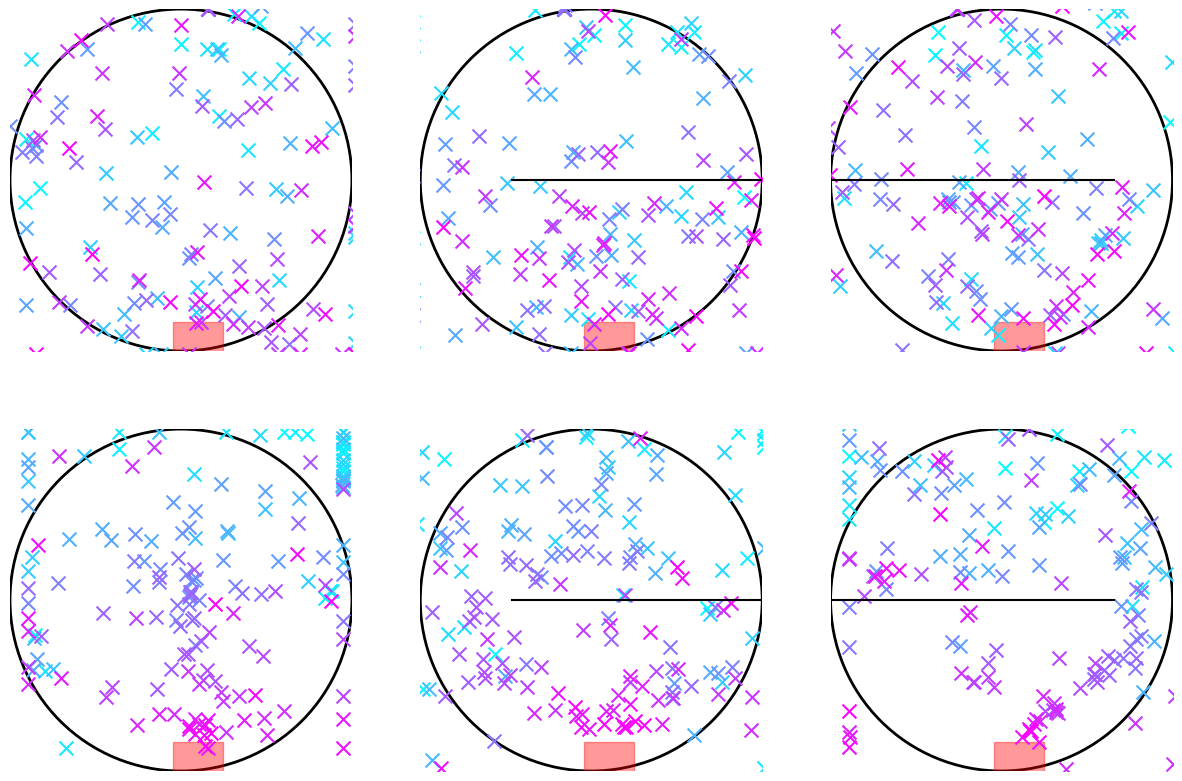

In [39]:
# select significantly tuned neurons in a condition

fig, axs = plt.subplots(2, len(cond_list), figsize=(15, 10))
for c in cond_list:
    sig_cells = np.where(sig_escape[cond_list.index(c),:])[0]
    mean_fr = np.nanmean(escp_tuna_dict['neural_matrix'][:, escp_tuna_dict['condition'] == int(cond_list.index(c))], axis=1)
    std_fr = np.nanstd(escp_tuna_dict['neural_matrix'][:, escp_tuna_dict['condition'] == int(cond_list.index(c))], axis=1)
    heatmap = escp_tuna_dict['fr_full'][cond_list.index(c), sig_cells,:]
    heatmap = np.divide(heatmap - mean_fr[sig_cells, np.newaxis], 
                        std_fr[sig_cells, np.newaxis], 
                        out=np.zeros_like(heatmap, dtype=np.float64), 
                        where=std_fr[sig_cells, np.newaxis] != 0)
    sort_idx = np.argsort(np.argmax(heatmap, axis=1))
    sig_cells = sig_cells[sort_idx]
    # get a colormap with as many colors as sig_cells
    colors = cm.cool(np.linspace(0, 1, len(sig_cells))) if len(sig_cells) > 0 else []
    for n in range(2):
        Arena(ax = axs[n,cond_list.index(c)], dim = PC_dict[c].item()["rate_map"][:,:,0].shape[0]-1, condition = c,
                barrier_coordinates = session.barrier_location[:-1], full_image = False)
    for idx, i in enumerate(sig_cells):
        color = colors[idx] if len(colors) > 0 else 'red'
        # exploration place cells
        rate_map = PC_dict[c].item()['rate_map'][:,:,i]
        popt = fit_peak_circular_2d(rate_map)
        if popt is not None:
            axs[0,cond_list.index(c)].scatter(popt[1], popt[2], color=color, marker='x', s=100, label='Fitted Peak' if idx == 0 else None)
        # homing place cells
        rate_map_homie = PC_homie_dict[c].item()['rate_map'][:,:,i]
        popt_homie = fit_peak_circular_2d(rate_map_homie)
        if popt_homie is not None:
            axs[1,cond_list.index(c)].scatter(popt_homie[1], popt_homie[2], color=color, marker='x', s=100, label='Fitted Peak' if idx == 0 else None)
